In [1]:
import pathlib

import pandas as pd

In [2]:
output_folder = pathlib.Path("../../data/outputs_nosync/outputs_ch/") # Change this for different outputs
prediction_runs = [fol for fol in output_folder.iterdir() if fol.is_dir()]
prediction_runs

[PosixPath('../../data/outputs_nosync/outputs_ch/biolog_mutual_info_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_pca_200'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_chi2_1000'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_nmf_200'),
 PosixPath('../../data/outputs_nosync/outputs_ch/biolog_f_1000')]

In [3]:
output_folder2 = pathlib.Path("../../data/outputs_combined_ch/") # Change this for different outputs
prediction_runs2 = [fol for fol in output_folder2.iterdir() if fol.is_dir()]
prediction_runs2

[PosixPath('../../data/outputs_combined_ch/biolog_chi2_1000')]

In [4]:
def read_csv_files(folder_list: list[pathlib.Path], file_name: str, reindex: bool = True):
    df_list = []
    for folder in folder_list:
        file_path = folder / file_name
        df = pd.read_csv(file_path, index_col=0)
        df_list.append(df)
    df_concat = pd.concat(df_list)
    if reindex:
        df_concat.index = list(range(df_concat.shape[0])) # type: ignore
    return df_concat

In [5]:
cv_scores_df1 = read_csv_files(prediction_runs, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df1

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,0.745098,0.736111,0.823529,0.583333,0.682927,0.935185,0.500000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,1,cluster30,biolog_mutual_info_1000
1,0.549020,0.564815,0.512821,0.833333,0.634921,0.677469,0.152535,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,2,cluster30,biolog_mutual_info_1000
2,0.509804,0.490741,0.444444,0.166667,0.242424,0.564815,-0.024246,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,3,cluster30,biolog_mutual_info_1000
3,0.549020,0.546584,0.500000,0.521739,0.510638,0.486025,0.092880,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,4,cluster30,biolog_mutual_info_1000
4,0.680000,0.674718,0.666667,0.608696,0.636364,0.855072,0.352862,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,5,cluster30,biolog_mutual_info_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
23035,0.877193,0.876232,0.843750,0.931034,0.885246,0.944581,0.758086,Carbon-a-D-Lactose,ch_biolog,1,uniref90,biolog_f_1000
23036,0.824561,0.822660,0.771429,0.931034,0.843750,0.847291,0.662686,Carbon-a-D-Lactose,ch_biolog,2,uniref90,biolog_f_1000
23037,0.625000,0.625000,0.571429,1.000000,0.727273,0.751913,0.377964,Carbon-a-D-Lactose,ch_biolog,3,uniref90,biolog_f_1000
23038,0.482143,0.482143,0.489362,0.821429,0.613333,0.713648,-0.048622,Carbon-a-D-Lactose,ch_biolog,4,uniref90,biolog_f_1000


In [6]:
cv_scores_df2 = read_csv_files(prediction_runs2, "all_feat_cv_scores_data.csv", reindex=True)
cv_scores_df2

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
0,0.745098,0.736111,0.823529,0.583333,0.682927,0.944444,0.500000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,1,combined,biolog_chi2_1000
1,0.647059,0.664352,0.575000,0.958333,0.718750,0.797840,0.398902,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,2,combined,biolog_chi2_1000
2,0.607843,0.597222,0.625000,0.416667,0.500000,0.745370,0.209165,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,3,combined,biolog_chi2_1000
3,0.568627,0.545031,0.538462,0.304348,0.388889,0.576087,0.102830,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,4,combined,biolog_chi2_1000
4,0.820000,0.810789,0.888889,0.695652,0.780488,0.903382,0.645402,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,5,combined,biolog_chi2_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
315,0.775862,0.775862,0.863636,0.655172,0.745098,0.920333,0.568535,Carbon-a-D-Lactose,ch_biolog,1,combined,biolog_chi2_1000
316,0.741379,0.741379,0.718750,0.793103,0.754098,0.775268,0.485363,Carbon-a-D-Lactose,ch_biolog,2,combined,biolog_chi2_1000
317,0.672414,0.672414,0.608696,0.965517,0.746667,0.668252,0.425628,Carbon-a-D-Lactose,ch_biolog,3,combined,biolog_chi2_1000
318,0.741379,0.741379,0.750000,0.724138,0.736842,0.834721,0.483046,Carbon-a-D-Lactose,ch_biolog,4,combined,biolog_chi2_1000


In [7]:
# cv_scores_df = pd.concat([cv_scores_df1[cv_scores_df1.run_id == "biolog_mutual_info_1000"], cv_scores_df2])
cv_scores_df = pd.concat([cv_scores_df1[cv_scores_df1.run_id == "biolog_chi2_1000"], cv_scores_df2])
cv_scores_df

,accuracy,balanced_accuracy,precision,recall,f1,roc_auc,matthews_corrcoef,name,category,fold_num,feature,run_id
11520,0.764706,0.754630,0.875000,0.583333,0.700000,0.930556,0.547813,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,1,cluster30,biolog_chi2_1000
11521,0.588235,0.611111,0.533333,1.000000,0.695652,0.901235,0.344265,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,2,cluster30,biolog_chi2_1000
11522,0.588235,0.569444,0.666667,0.250000,0.363636,0.672068,0.181848,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,3,cluster30,biolog_chi2_1000
11523,0.529412,0.520963,0.476190,0.434783,0.454545,0.509317,0.042389,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,4,cluster30,biolog_chi2_1000
11524,0.720000,0.708535,0.764706,0.565217,0.650000,0.867955,0.438806,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog,5,cluster30,biolog_chi2_1000
...,...,...,...,...,...,...,...,...,...,...,...,...
315,0.775862,0.775862,0.863636,0.655172,0.745098,0.920333,0.568535,Carbon-a-D-Lactose,ch_biolog,1,combined,biolog_chi2_1000
316,0.741379,0.741379,0.718750,0.793103,0.754098,0.775268,0.485363,Carbon-a-D-Lactose,ch_biolog,2,combined,biolog_chi2_1000
317,0.672414,0.672414,0.608696,0.965517,0.746667,0.668252,0.425628,Carbon-a-D-Lactose,ch_biolog,3,combined,biolog_chi2_1000
318,0.741379,0.741379,0.750000,0.724138,0.736842,0.834721,0.483046,Carbon-a-D-Lactose,ch_biolog,4,combined,biolog_chi2_1000


In [8]:

score_columns = ["balanced_accuracy", "matthews_corrcoef", "accuracy",  "f1", "precision", "recall", "roc_auc" ]

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/home/dileep/Documents/Work/trait-prediction

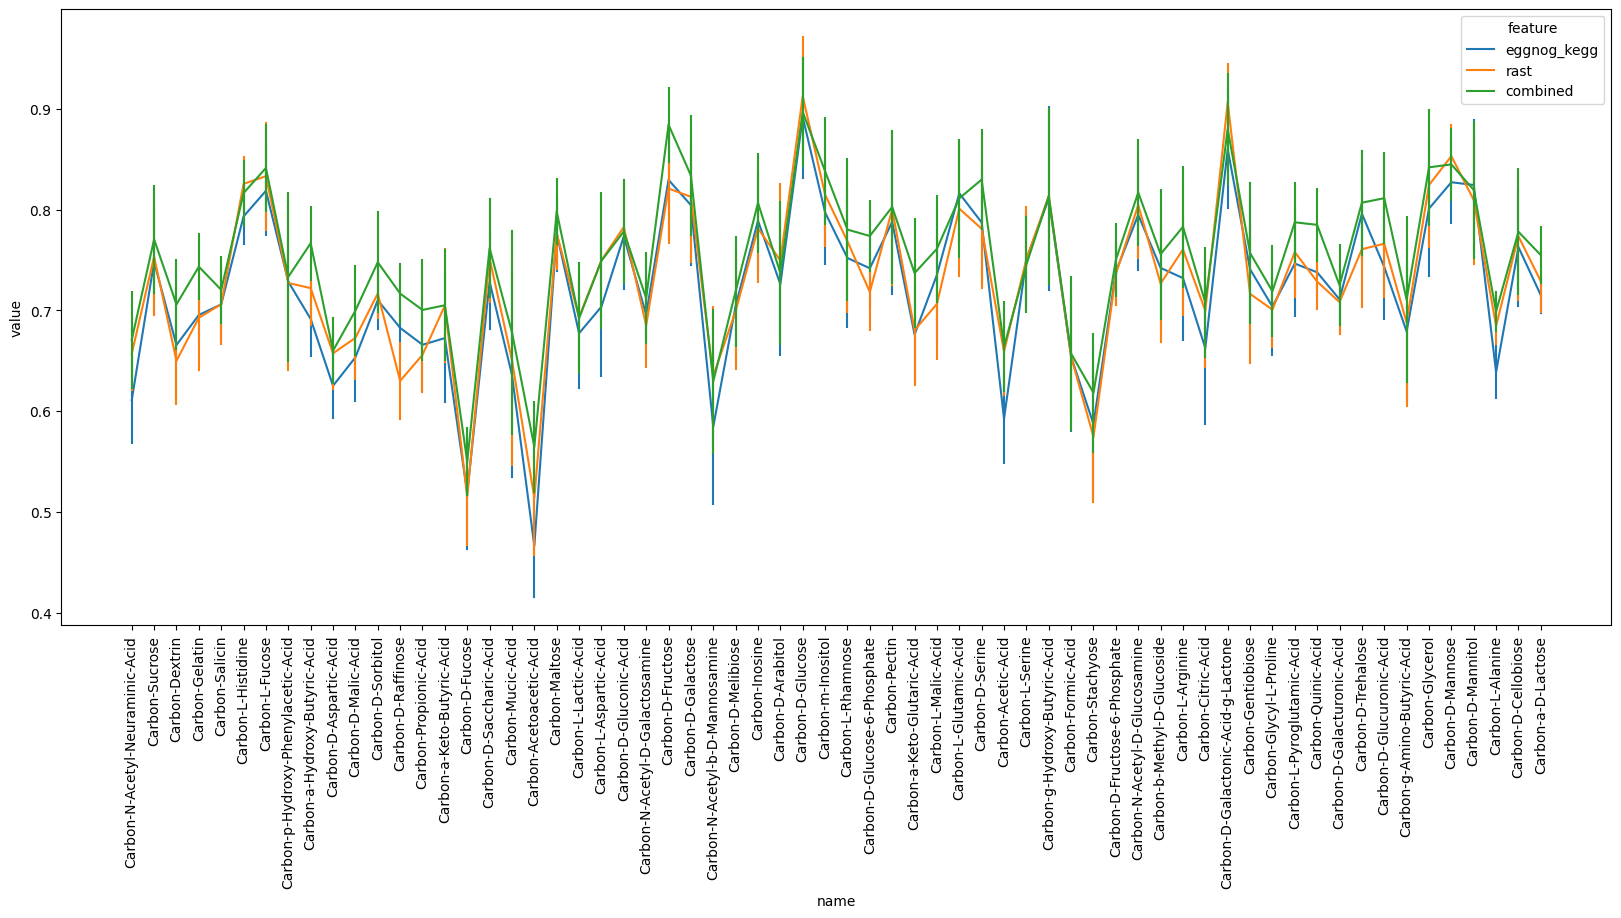

In [10]:
cols = score_columns
plot_data = (
    cv_scores_df
    .melt(id_vars=["name", "feature"], value_vars=score_columns, var_name="score", value_name="value")
)
plot_data = plot_data[plot_data.score.isin(["balanced_accuracy"])]
plot_data = plot_data[plot_data.feature.isin(["eggnog_kegg", "combined", "rast"])]

plt.figure(figsize=(20,8))
sns.lineplot(data=plot_data, x="name", y="value", errorbar="se", err_style="bars", hue="feature")
plt.tick_params(axis='x', rotation=90, which="both");
# for i, ax in enumerate(g.axes.flat):
#     ax.tick_params(axis='x', rotation=90, which="both");

> NOTE:
> The lower performance of the combined dataset on some of the phenotypes could be because it has 20 fewer data points (i.e. 10% fewer) compared to the original dataset!

In [11]:
from matplotlib.patches import Rectangle

In [12]:
set(cv_scores_df.run_id)

{'biolog_chi2_1000'}

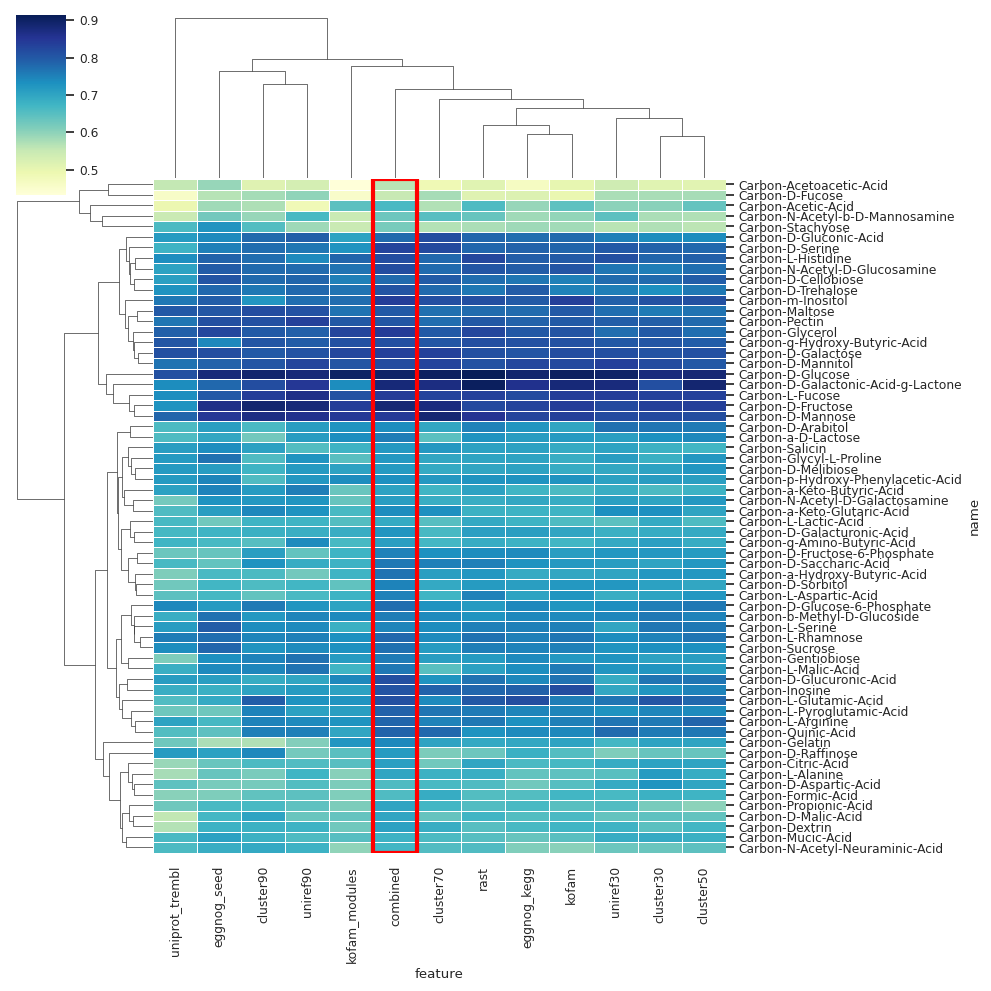

In [17]:
plot_data = (
    cv_scores_df
    # .loc[cv_scores_df.run_id == "biolog_mutual_info_1000", ["feature", "name", "balanced_accuracy"]]
    .loc[cv_scores_df.run_id == "biolog_chi2_1000", ["feature", "name", "balanced_accuracy"]]
    .groupby(by=["feature", "name"])
    .mean()
    .reset_index()
    .sort_values(by="balanced_accuracy", ascending=False)
    .pivot(index="name", columns="feature", values="balanced_accuracy")
)
sns.set_theme(font_scale=0.8)
g = sns.clustermap(plot_data,  linewidths=.5, cmap="YlGnBu", yticklabels=1)
ax = g.ax_heatmap

# ax.add_patch(Rectangle((1, 0), 1, 40, fill=False, edgecolor='red', lw=3))
ax.add_patch(Rectangle((5, 0), 1, 64, fill=False, edgecolor='red', lw=3))
plt.show()

In [14]:
def common_features(group):
    df = group.drop(["fold_num", "category", "feature", "run_id", "name"], axis=1)
    n = df.shape[0]
    m = df.shape[1]
    feature_list = []
    for i in range(n):
        feature_list.append(set(df.iloc[i]))
    common_features = set.intersection(*feature_list)
    return len(common_features) / m * 100

In [15]:
cv_features_df = read_csv_files(prediction_runs2, "all_feat_cv_features_data.csv", reindex=True)
cv_features_df

,feat_1,feat_2,feat_3,feat_4,feat_5,feat_6,feat_7,feat_8,feat_9,feat_10,...,feat_16,feat_17,feat_18,feat_19,feat_20,fold_num,feature,run_id,name,category
0,K00836.1,UniRef30_A0A068VSB3,K05879.1,SSO:000004966,K00836,K23274,K03381,K02598,SSO:000037535,K03294,...,399_1,K15034.1,SSO:000012949,625_4567,348_5474,1,combined,biolog_chi2_1000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog
1,K00885,399_1,K07076,790_2438,SSO:000037535,399_4963,SSO:000009725,K16090,K01639,K07485,...,K11476,K15034.1,K02598,K01523,1212_1282,2,combined,biolog_chi2_1000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog
2,K07485,SSO:000037535,790_2438,K15034.1,399_1,SSO:000004966,K01711.1,SSO:000003073,1030_3500,69_6656,...,SSO:000000966,215_31,K16044,629_2659.2,K07006,3,combined,biolog_chi2_1000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog
3,K01711,K01711.1,K01639,155_4863,SSO:000004966,K07485,69_6656,K07482,K00784,SSO:000023549,...,1212_1282,SSO:000037535,K11476,SSO:000018986,625_4567,4,combined,biolog_chi2_1000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog
4,K07076,SSO:000026969,K16090,1285_2740,399_1,K03580.1,K14259,399_4963,1212_1282,SSO:000023549,...,SSO:000017493,K00885,K16090.1,K01447,276_1815,5,combined,biolog_chi2_1000,Carbon-N-Acetyl-Neuraminic-Acid,ch_biolog
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
315,K03200.1,382_538,SSO:000002774,K01185,K02805,SSO:000013193,905_2945,K00971,K13953,K13653,...,963_288,K00003,K07039,SSO:000016637,K13653.1,1,combined,biolog_chi2_1000,Carbon-a-D-Lactose,ch_biolog
316,382_538,K00996,SSO:000004959,K01007,K01286,K07814.1,K07258,SSO:000026099,SSO:000000428,SSO:000017946,...,963_288,K12372,K03200.1,SSO:000025235,SSO:000000866,2,combined,biolog_chi2_1000,Carbon-a-D-Lactose,ch_biolog
317,K01286,K13653.1,K07258,K13653,808_3588,SSO:000024934,102_616.1,963_288,K03200.1,K03417,...,K08191.1,SSO:000021760,K00389,K03200,K00768,3,combined,biolog_chi2_1000,Carbon-a-D-Lactose,ch_biolog
318,382_538,K00955,K17050,K00278,SSO:000026099,963_288,K00003,K01733,K01286,SSO:000021760,...,K00548,SSO:000034267,K13924,K16568,SSO:000041695,4,combined,biolog_chi2_1000,Carbon-a-D-Lactose,ch_biolog


/tmp/ipykernel_916765/532998193.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  plot_data = cv_features_df.groupby(by=["name"]).apply(common_features).reset_index()


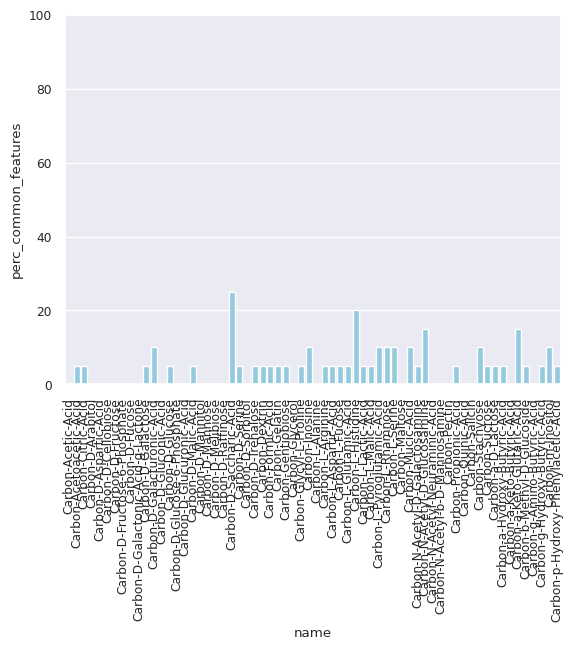

In [16]:
plot_data = cv_features_df.groupby(by=["name"]).apply(common_features).reset_index()
plot_data.columns = ["name", "perc_common_features"]
g = sns.barplot(data=plot_data, x="name", y="perc_common_features", color="skyblue")
plt.ylim(0, 100)
plt.tick_params(axis='x', rotation=90, which="both");
# for ax in g.axes.flat:
#     ax.tick_params(axis='x', rotation=90, which="both");

> NOTE:
> The low number of common features is probably because of the high correlation about the features in the combined dataset.